# Bootstrap analysis at 200ps

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\QT3 User Facility\Documents\qick-dawg\Analysis\bootstrap_experiment_1846MHz.csv")
print(df)

    bootstrap_index         signal      reference
0               1.0  174764.307692  213675.323077
1               2.0  175009.476923  212936.861538
2               3.0  177496.615385  213734.400000
3               4.0  177564.553846  212865.969231
4               5.0  175588.430769  213223.384615
5               6.0  175186.707692  213669.415385
6               7.0  174492.553846  212671.015385
7               8.0  174793.846154  213509.907692
8               9.0  175948.800000  212112.738462
9              10.0  177168.738462  213072.738462
10             11.0  174445.292308  213690.092308
11             12.0  174687.507692  212857.107692


In [3]:
# ---------- Pauli matrices ----------
sigma_x = np.array([[0, 1], [1, 0]], complex)
sigma_y = np.array([[0, -1j], [1j, 0]], complex)
sigma_z = np.array([[1, 0], [0, -1]], complex)
I2 = np.eye(2)

# ---------- Helper functions ----------
def unitary_from_axis_angle(nx, ny, nz, theta):
    """Return exp(-i * theta/2 * (n·σ))."""
    n = np.array([nx, ny, nz], float)
    n /= np.linalg.norm(n)
    n_dot_sigma = n[0]*sigma_x + n[1]*sigma_y + n[2]*sigma_z
    c, s = np.cos(theta/2), np.sin(theta/2)
    return c*I2 - 1j*s*n_dot_sigma

def process_fidelity(U_target, U_actual):
    """Quantum process fidelity (normalized, real in [0,1])."""
    overlap = np.trace(U_target.conj().T @ U_actual)
    return float(abs(overlap)**2 / 4.0)

# ---------- Ideal unitaries ----------
def ideal_pi_x():   return unitary_from_axis_angle(1, 0, 0, np.pi)
def ideal_pi_y():   return unitary_from_axis_angle(0, 1, 0, np.pi)
def ideal_pi2_x():  return unitary_from_axis_angle(1, 0, 0, np.pi/2)
def ideal_pi2_y():  return unitary_from_axis_angle(0, 1, 0, np.pi/2)

# ---------- Faulty unitaries ----------
def faulty_pi_x(phi, eps_y, eps_z):
    return unitary_from_axis_angle(1, eps_y, eps_z, np.pi + 2*phi)

def faulty_pi_y(chi, v_x, v_z):
    return unitary_from_axis_angle(v_x, 1, v_z, np.pi + 2*chi)

def faulty_pi2_x(phi_p, eps_y_p, eps_z_p):
    return unitary_from_axis_angle(1, eps_y_p, eps_z_p, np.pi/2 + 2*phi_p)

def faulty_pi2_y(chi_p, v_x_p, v_z_p):
    return unitary_from_axis_angle(v_x_p, 1, v_z_p, np.pi/2 + 2*chi_p)

# computes process fidelities for all gates given the signal vector
def compute_fidelities(signal):
    # Unpack signal vector into parameters
    pi2X = [signal[0], signal[6], signal[7]]   # [phi', eps_y', eps_z']
    pi2Y = [signal[1], signal[8], signal[9]]   # [chi', v_x', v_z']
    piX  = [signal[2], signal[10], signal[5]]  # [phi, eps_y, eps_z]
    piY  = [signal[3], signal[11], signal[4]]  # [chi, v_x, v_z]

    # Build unitaries
    U_pi2X = faulty_pi2_x(*pi2X)
    U_pi2Y = faulty_pi2_y(*pi2Y)
    U_piX  = faulty_pi_x(*piX)
    U_piY  = faulty_pi_y(*piY)

    # Ideal ones
    U_pi2X_ideal = ideal_pi2_x()
    U_pi2Y_ideal = ideal_pi2_y()
    U_piX_ideal  = ideal_pi_x()
    U_piY_ideal  = ideal_pi_y()

    # Compute process fidelities
    fidelities = {
        "π/2_X": process_fidelity(U_pi2X_ideal, U_pi2X),
        "π/2_Y": process_fidelity(U_pi2Y_ideal, U_pi2Y),
        "π_X"  : process_fidelity(U_piX_ideal,  U_piX),
        "π_Y"  : process_fidelity(U_piY_ideal,  U_piY),
    }

    return fidelities

def solve_bootstrap_signals(S, omit_row=-1, fixed_index=0):
    """
    Solve A E = S for the error vector E = (eps'_y, eps'_z, v'_x, v'_z, eps_y, v_x)
    using the bootstrap tomography matrix from the supplement.
    
    Strategy:
      - We fix the variable at `fixed_index` (default 0 => eps'_y = 0).
      - Remove the corresponding column from A (unknown removed) and drop one
        redundant equation (row index `omit_row`, default -1 => last row).
      - Solve the reduced linear system. If the reduced matrix is singular or
        poorly conditioned, fall back to np.linalg.lstsq.
    
    Inputs:
      S : array-like of length 6 (S1..S6)
      omit_row : index of the row to drop (0..5). Default -1 (last row).
      fixed_index : index of the fixed unknown in E (0..5). Default 0.
    
    Returns:
      E : np.ndarray shape (6,) with the solved error parameters, with the
          `fixed_index` component set to 0.
      info : dict with keys 'residual' (norm of A E - S) and 'method' used.
    """
    S = np.asarray(S, dtype=float).reshape(6)
    # Full A matrix as given in the supplement (6x6) https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.105.077601?__cf_chl_tk=OJit3IH_f_.tMb6W6g0SHQM6.uV36H9ieFmu3en4wj4-1759769753-1.0.1.1-67pXH.nAif8JKOAf_MDe0Gjfad2FLsFhsTxxyD9G7lo#supplemental
    A = np.array([
        [-1, -1, -1, -1,  0,  0],
        [-1,  1, -1,  1,  0,  0],
        [-1,  1,  1, -1,  2,  0],
        [-1, -1,  1,  1,  2,  0],
        [ 1, -1, -1,  1,  0,  2],
        [ 1,  1, -1, -1,  0,  2],
    ], dtype=float)
    
    # Validate indices
    if not (0 <= fixed_index <= 5):
        raise ValueError("fixed_index must be in 0..5")
    if not (-6 <= omit_row <= 5):
        raise ValueError("omit_row must be in -6..5 (python-style).")
    # Normalize omit_row into python positive index
    omit_row = omit_row % 6
    
    # Remove the fixed unknown's column and the omitted row
    A_reduced = np.delete(A, fixed_index, axis=1)   # shape (6,5)
    A_reduced = np.delete(A_reduced, omit_row, axis=0)  # shape (5,5)
    S_reduced = np.delete(S, omit_row, axis=0)     # shape (5,)
    
    # Try direct solve first
    method = None
    try:
        x_reduced = np.linalg.solve(A_reduced, S_reduced)
        method = 'solve'
    except np.linalg.LinAlgError:
        # fall back to least-squares (robust to singular / noisy data)
        x_reduced, residuals, rank, s = np.linalg.lstsq(A_reduced, S_reduced, rcond=None)
        method = 'lstsq'
    
    # Reconstruct full E by inserting the fixed zero at fixed_index
    E = np.insert(x_reduced, fixed_index, 0.0)
    
    # Compute residual for the original 6x6 system AE - S
    residual = np.linalg.norm(A.dot(E) - S)
    
    info = {'residual': float(residual), 'method': method}
    return E, info

def calculate_bootstrap_signals(data):
    reference_value = 0.5 # b/c pi/2 should give 0.5
    data = np.array(data) - reference_value
    phi_prime = data[0]/-2
    chi_prime = data[1]/-2
    phi = data[2]/2 - phi_prime
    chi = data[3]/2 - chi_prime
    vz = (data[4] - 2 * phi_prime) / -2
    epsz = (data[5] - 2 * chi_prime) / 2
    
    E_sol, info = solve_bootstrap_signals(data[6:], omit_row=-1, fixed_index=0)
    
    names = ["eps'_y", "eps'_z", "v'_x", "v'_z", "eps_y", "v_x"]
    print("Solved error vector E (in order {}):".format(names))
    for n, val in zip(names, E_sol):
        print(f"  {n:7s} = {val:+.6f}")
    print(f"\nMethod used: {info['method']}")
    print(f"Residual ||A E - S||_2 = {info['residual']:.3e}")

    E_sol = np.concatenate([np.array([phi_prime, chi_prime, phi, chi, vz, epsz]), E_sol])
    return E_sol

def plot_bootstrap_processed(data, ymin, ymax):
    exp_nums = np.arange(1, 13)
    xlabels = [r"$\pi/2_X$", r"$\pi/2_Y$",
               r"$\pi/2_X - \pi_X$", r"$\pi/2_Y - \pi_Y$", r"$\pi_Y - \pi/2_X$", r"$\pi_X - \pi/2_Y$",
               r"$\pi/2_Y - \pi/2_X$", r"$\pi/2_X - \pi/2_Y$",
               r"$\pi/2_X - \pi_X - \pi/2_Y$", r"$\pi/2_Y - \pi_X - \pi/2_X$", r"$\pi/2_X - \pi_Y - \pi/2_Y$", r"$\pi/2_Y - \pi_Y - \pi/2_X$"]
    # normalize based on prior rabi data at same gain

    print("Normalizing based on prior Rabi data at same gain with ymax =", ymax, " and ymin =", ymin)
    y_scaled = (data - ymin) / (ymax - ymin)
    fig, ax = plt.subplots(1, 1, sharex=True, figsize=(8, 6))
    ax.plot(exp_nums, y_scaled, '-o')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('$P_x$')
    ax.set_xticks(exp_nums)
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    title = "Bootstrap Processed Scan"
    fig.suptitle(title)
    plt.tight_layout()

    # now calculate the error signals
    fig, ax = plt.subplots(2, 2, figsize=(8, 6))
    signal = calculate_bootstrap_signals(y_scaled)
    pi2X = [signal[0], signal[6], signal[7]]
    pi2X_labels = [r"$\phi'$", r"$\varepsilon_y'$", r"$\varepsilon_z'$"]
    pi2Y = [signal[1], signal[8], signal[9]]
    pi2Y_labels = [r"$\chi'$", r"$\nu_x'$", r"$\nu_z'$"]
    piX = [signal[2], signal[10], signal[5]]
    piX_labels = [r"$\phi$", r"$\varepsilon_y$", r"$\varepsilon_z$"]
    piY = [signal[3], signal[11], signal[4]]
    piY_labels = [r"$\chi$", r"$\nu_x$", r"$\nu_z$"]
    fidelity = compute_fidelities(signal)
    print("\nProcess Fidelities:")
    for gate, fid in fidelity.items():
        print(f"  {gate:6s} : {fid:.6f}")
    ax[0,0].bar(pi2X_labels, pi2X)
    ax[0,0].set_title(r'$\pi/2_X$ Errors with $F_p = $ {:.6f}'.format(fidelity["π/2_X"]))
    ax[0,1].bar(pi2Y_labels, pi2Y)
    ax[0,1].set_title(r'$\pi/2_Y$ Errors with $F_p = $ {:.6f}'.format(fidelity["π/2_Y"]))
    ax[1,0].bar(piX_labels, piX)
    ax[1,0].set_title(r'$\pi_X$ Errors with $F_p = $ {:.6f}'.format(fidelity["π_X"]))
    ax[1,1].bar(piY_labels, piY)
    ax[1,1].set_title(r'$\pi_Y$ Errors with $F_p = $ {:.6f}'.format(fidelity["π_Y"]))
    ax[0,0].set_ylabel('Error Magnitude')
    ax[1,0].set_ylabel('Error Magnitude')
    plt.tight_layout()

In [4]:
def compute_onoff_from_df(df):
    signal = df["signal"].values
    reference = df["reference"].values
    return signal / reference


def analyze_bootstrap_df(df, ymin, ymax):
    exp_nums = np.arange(1, 13)

    # Step 1: on/off
    onoff = compute_onoff_from_df(df)

    # Step 2: plot raw
    plt.figure(figsize=(6,4))
    plt.plot(exp_nums, onoff, '-o')
    plt.xlabel("Bootstrap Experiment Number")
    plt.ylabel("Signal / Reference")
    plt.title("Raw On/Off")
    plt.tight_layout()

    plot_bootstrap_processed(onoff, ymin, ymax)

Normalizing based on prior Rabi data at same gain with ymax = 0.99709762  and ymin = 0.64484002
Solved error vector E (in order ["eps'_y", "eps'_z", "v'_x", "v'_z", 'eps_y', 'v_x']):
  eps'_y  = +0.000000
  eps'_z  = +0.004832
  v'_x    = +0.000236
  v'_z    = +0.006064
  eps_y   = +0.006191
  v_x     = -0.006870

Method used: solve
Residual ||A E - S||_2 = 1.597e-03

Process Fidelities:
  π/2_X  : 0.999967
  π/2_Y  : 0.999890
  π_X    : 0.999536
  π_Y    : 0.999939


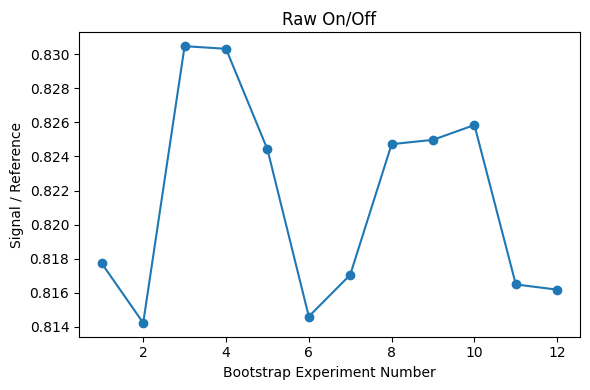

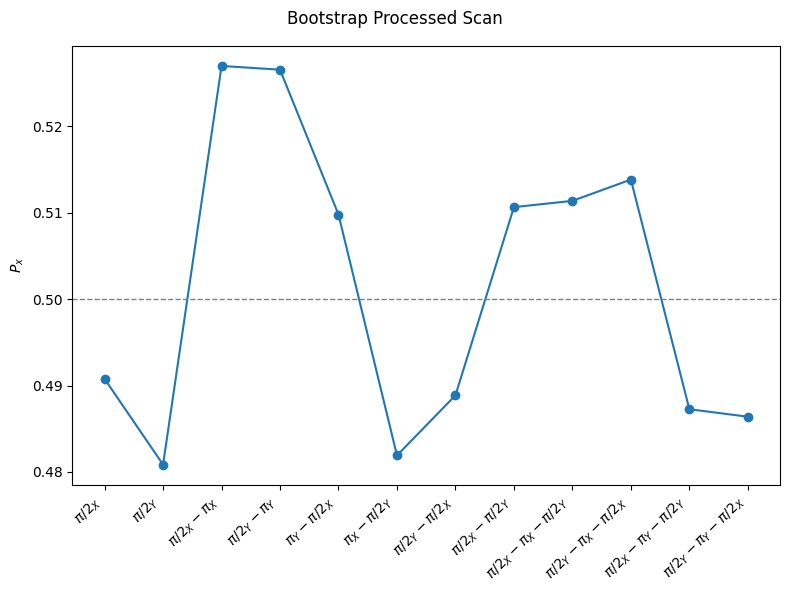

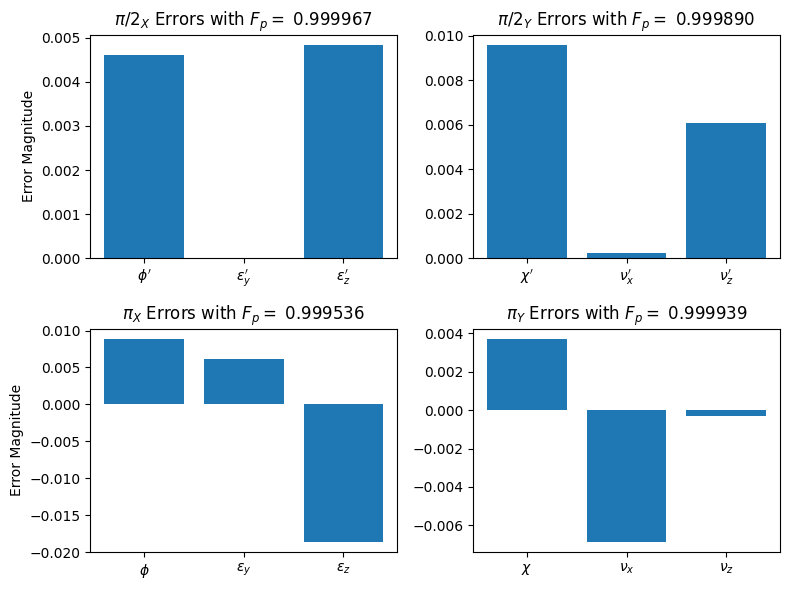

In [ ]:
max_rabi = 0.99709762
min_rabi = 0.64484002 

results = analyze_bootstrap_df(df, min_rabi, max_rabi)